In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import torch
from mtrain.disk import DiskImage, DiskBooleanMask
from mtrain.utils import mkdir

In [120]:
DS = Path("../../datasets/")
BASE = DS / "test-samples"
NEG_MASKING_V1 = BASE / "neg-masking" / "V1"
ROCKS = NEG_MASKING_V1 / "rocks"
SAMPLES_MAPILLARY = NEG_MASKING_V1 / "samples_mapillary"
ROCKS_TXT_FILE = ROCKS / "clip_query_res.txt"
ROCKS_DATA_DIR = mkdir(ROCKS / "data")
ROCKS_CVAT_DIR = mkdir(ROCKS / "cvat")
ROCKS_DS_DIR = ROCKS / "classification" / "crop_level"

SAMPLES_MAPILLARY.exists(), ROCKS.exists()

(True, True)

# convert 255 to 1 masks if needed

Some masks were accidentally using 255 for foreground instead of 1, you can use this to change them

In [4]:
from tqdm import tqdm
import shutil


def show_masks_unique(dirs, fname):
    uq = set()
    for d in tqdm(dirs):
        uq.add(tuple(np.unique(DiskBooleanMask.load(d / fname))))
    return uq


def fix_masks_unique(dirs):
    for d in tqdm(dirs):
        mask = DiskBooleanMask.load(d / "mask.png")
        mask = mask.astype(bool).astype(np.uint8)
        DiskBooleanMask.save(mask, d / "m1.png")


def make_m1_mask(dirs):
    for d in tqdm(dirs):
        shutil.move(d / "m1.png", d / "mask.png")


def verify_m1_and_masks(dirs):
    for d in tqdm(dirs):
        mask, m1 = d / "mask.png", d / "m1.png"
        mask, m1 = DiskBooleanMask.load(mask), DiskBooleanMask.load(m1)
        assert np.all(mask.astype(bool) == m1.astype(bool))
    print("all good")

# Model training

## Dataset

In [139]:
from torchvision.transforms import v2
from torchvision import tv_tensors
from PIL import Image


def _is_valid_dir(direc: Path):
    valid = (
        direc.is_dir()
        and (direc / "image.jpg").exists()
        and (direc / "mask.png").exists()
    )
    return valid


def get_ds_dirs(ds_root, labels):
    res = []
    for label in labels:
        cls_root = ds_root / label
        print(cls_root.name)
        if not cls_root.is_dir():
            continue
        for d in cls_root.glob("*"):
            if _is_valid_dir(d):
                res.append(d)
    random.shuffle(res)
    return res


def _label_func(d: Path):
    return Path(d).parent.name


def _validate_labels_in_dirs(dirs, label_by_idx):
    for d in dirs:
        label = _label_func(d)
        if label not in label_by_idx:
            raise Exception(
                f"Label={label} not found for directory={d}. label_by_index={label_by_idx}"
            )


class MaskClassificationDataset(torch.utils.data.Dataset):
    RESIZE_SIZE = (220, 220)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    def __init__(
        self,
        dirs: list[Path | str],
        norm_stats: tuple[list[float], list[float]],
        labels: list[
            str
        ],  # make sure these are always in the same order, new labels should be appended
        train: bool,
    ):
        self.mean = torch.tensor(norm_stats[0])
        self.std = torch.tensor(norm_stats[1])
        self.dirs = [d for d in map(Path, dirs) if _is_valid_dir(d)]
        self.labels = labels
        self.label_by_idx = {label: i for i, label in enumerate(self.labels)}
        train_tfms = v2.Compose(
            [
                v2.Resize(200, antialias=True),
                v2.RandomCrop(130),
                v2.RandomHorizontalFlip(p=0.5),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
                v2.ToPureTensor(),
            ]
        )
        eval_tfms = v2.Compose(
            [
                v2.Resize(130, antialias=True),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
                v2.ToPureTensor(),
            ]
        )
        self.tfms = train_tfms if train else eval_tfms
        _validate_labels_in_dirs(self.dirs, self.label_by_idx)

    def __len__(self):
        return len(self.dirs)

    def __getitem__(self, index):
        d = self.dirs[index]

        # load individual as tensors
        img = tv_tensors.Image(Image.open(d / "image.jpg").convert("RGB"))
        mask = tv_tensors.Mask(Image.open(d / "mask.png").convert("L"))

        # tfms then combine
        t_img, t_mask = self.tfms([img, mask])
        combined = torch.cat([t_img, t_mask], dim=0)

        # label tensor
        label = _label_func(d)
        label_idx = self.label_by_idx[label]
        label_tensor = torch.Tensor([label_idx]).squeeze()

        return (combined, label_tensor)

In [246]:
from sklearn.model_selection import train_test_split

LABELS = ["trash", "other"]
AREA_THRES = 5

def is_area_greater(d, pixels_count_thres: int):
    n = np.array(Image.open(d / "mask.png").convert("L")).sum()
    return n > pixels_count_thres

def get_area(d):
    return np.array(Image.open(d / "mask.png").convert("L")).sum()


total_dirs = get_ds_dirs(ROCKS_DS_DIR, LABELS)
areas_and_dirs = [(get_area(d), d) for d in total_dirs]
dirs = [d for (a,d) in areas_and_dirs if a > AREA_THRES or a == 0]

print(f"total directories scanned: {len(total_dirs)}")
print(f"filtered directories: {len(dirs)}")


labels = [_label_func(d) for d in dirs]
train_dirs, valid_dirs = train_test_split(
    dirs, test_size=0.2, stratify=labels, random_state=42
)

trash
other
total directories scanned: 5720
filtered directories: 5568


In [247]:
from fastai.vision.all import imagenet_stats

train_ds = MaskClassificationDataset(train_dirs, imagenet_stats, LABELS, train=True)
valid_ds = MaskClassificationDataset(valid_dirs, imagenet_stats, LABELS, train=False)

### Visualise single tensors

In [248]:
from mtrain.smallnet.unet.extract.draw import overlay_mask_on_img
from mtrain.utils import show


def denormalize(tf_img):
    std = torch.Tensor(MaskClassificationDataset.IMAGENET_STD)
    mean = torch.Tensor(MaskClassificationDataset.IMAGENET_MEAN)
    tf_img = (tf_img * std + mean).clamp(0, 1)
    return tf_img

def get_image_from_input_tensor(t_img):
    return denormalize(t_img[:3].permute(1,2,0))


def show_single(d, data_point):
    orig_img, orig_mask = (
        plt.imread(d / "image.jpg"),
        plt.imread(d / "mask.png"),
    )
    tf_img, tf_mask = data_point[0][:3].permute(1, 2, 0), data_point[0][3]
    tf_img = denormalize(tf_img)
    tf_img, tf_mask = (tf_img.numpy() * 255).astype(np.uint8), tf_mask.numpy().astype(bool)
    show(
        [
            orig_img,
            orig_mask,
            overlay_mask_on_img(orig_img, orig_mask.astype(bool)),
            tf_img,
            tf_mask,
            overlay_mask_on_img(tf_img, tf_mask),
        ],
        (10, 10),
        ncols=3,
        axis="off",
    )


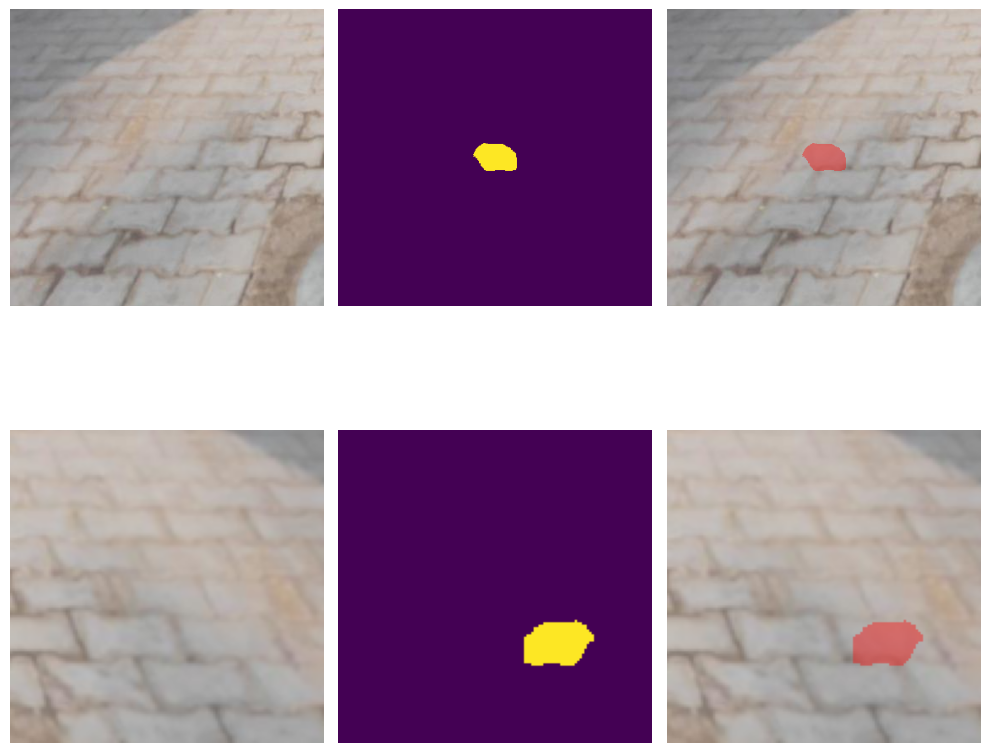

In [254]:
# train test, see if transforms are working correctly
# you should see synced randomized cropping on multiple calling
idx = 9
show_single(train_dirs[idx], train_ds[idx])

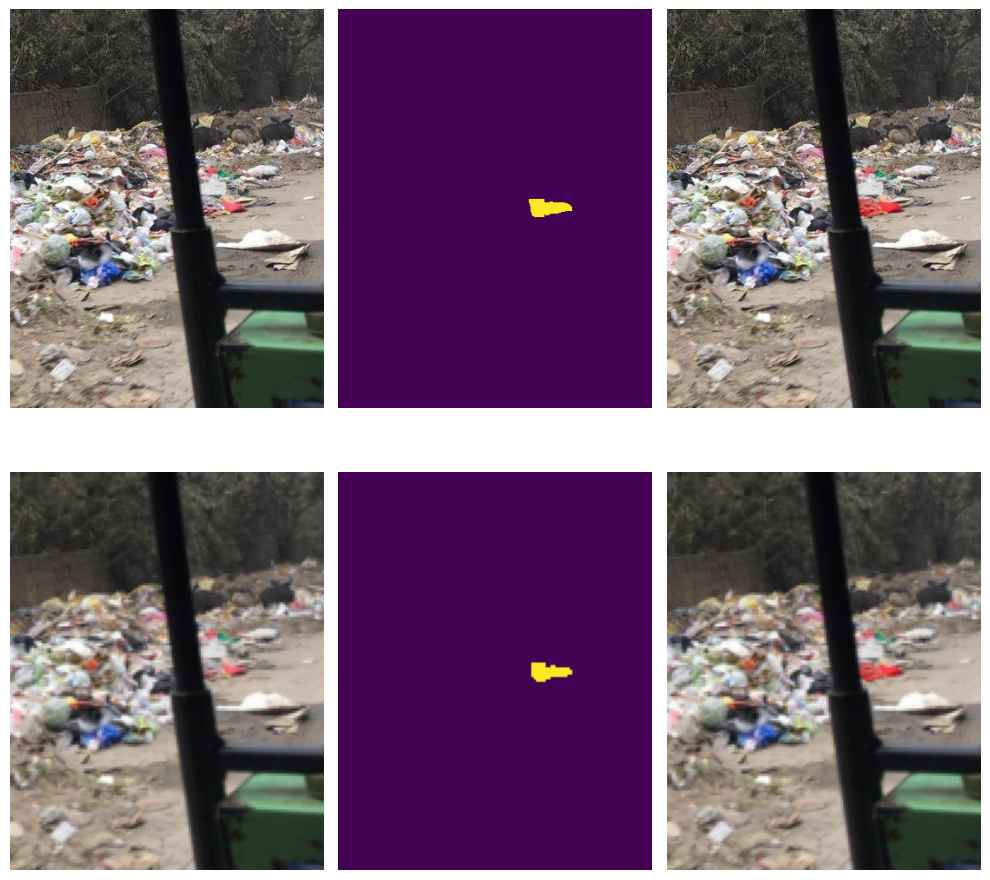

In [257]:
# valid test, see if transforms are working correctly
# no randomized cropping for flipping on multiple calls
idx = 11
show_single(valid_dirs[idx], valid_ds[idx])

# Model train

- Current status: very imbalanced, need more points for trash and unknown

In [258]:
from fastai.data.core import DataLoaders, default_device
from fastai.vision.all import (
    vision_learner,
    mobilenet_v3_small,
    mobilenet_v3_large,
    accuracy,
    F1Score,
    CrossEntropyLossFlat,
    ProgressCallback,
)

dls = DataLoaders.from_dsets(train_ds, valid_ds, device=default_device())

In [259]:
from collections import defaultdict

def get_label_stats(dirs):
    counts = defaultdict(lambda: 0)
    for d in dirs:
        counts[_label_func(d)] += 1
    return {
        "counts": dict(counts)
    }

In [260]:
LABELS, train_ds.label_by_idx, get_label_stats(dirs)

(['trash', 'other'],
 {'trash': 0, 'other': 1},
 {'counts': {'other': 4525, 'trash': 1043}})

In [261]:
# load a learner
def load_our_learner(dls, model_arch, weights, pth_path=None):
    learn = vision_learner(
        dls,
        model_arch,
        n_in=4,
        metrics=[accuracy, F1Score(average="macro")],
        loss_func=CrossEntropyLossFlat(weight=weights),
        n_out=len(LABELS),
        normalize=False,
    )
    learn = learn.remove_cb(ProgressCallback)
    if pth_path is not None:
        pth_path = Path(pth_path)
        if pth_path.suffix == '.pth':
            print("WARN: the path you should pass should not have suffix .pth")
        learn = learn.load(pth_path)
    return learn

In [262]:
counts = torch.tensor([1000, 2000], dtype=torch.float32)
weights = 1 / counts
weights = weights / weights.sum()  # normalize
weights = weights.to(default_device())

learn = load_our_learner(dls, mobilenet_v3_large, weights)

learn = vision_learner(
    dls,
    mobilenet_v3_large,
    n_in=4,
    metrics=[accuracy, F1Score(average="macro")],
    loss_func=CrossEntropyLossFlat(weight=weights),
    n_out=len(LABELS),
    normalize=False,
)
learn = learn.remove_cb(ProgressCallback)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
learn.fine_tune(5)

In [ ]:
learn.fit_one_cycle(20, lr_max=slice(1e-4, 1e-3))

[0, 0.29341477155685425, 0.2837606966495514, 0.8854895234107971, 0.798768689533861, '00:59']
[1, 0.2726561725139618, 0.28153032064437866, 0.8933566212654114, 0.8144585360665763, '00:59']


In [ ]:
model_dir = mkdir(DS / "models" / "trash_classification")
learn.save((model_dir / "mobilenet_large_mask_thres_6_25_epochs").resolve())

Path('/Users/hariomnarang/Desktop/personal/roads/datasets/models/trash_classification/mobilenet_large_1_1_weights.pth')

# Visualization functions

In [ ]:
import matplotlib.pyplot as plt

BASE_MODEL_DIR = Path("../../datasets/models")

def show_confusion_matrix(learn, dls):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    preds, targs = learn.get_preds(dl=dls.valid)
    pred_classes = preds.argmax(dim=1)

    cm = confusion_matrix(targs, pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot()


def draw_mask_bboxes(ax, mask):
    mask_uint8 = mask.astype(np.uint8)
    n, labeled = cv2.connectedComponents(mask_uint8)
    for i in range(1, n):  # skip 0 (background)
        ys, xs = np.where(labeled == i)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                              linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

def show_images(dataset, idxs, preds, title, nrows=4):
    n = nrows * 5
    fig, axes = plt.subplots(nrows, 5, figsize=(20, 20))
    fig.suptitle(title)
    for ax, idx in zip(axes.flat, idxs[:n]):
        img, label = dataset[idx.item()]
        t_img = denormalize(img[:3].permute(1,2,0))
        t_mask = img[3].numpy().astype(bool)
        ax.imshow(t_img)  # adjust if your img has 4 channels
        draw_mask_bboxes(ax, t_mask)
        score = preds[idx.item(), 0].item()  # prob of trash class
        ax.set_title(f"{idx.item()} | trash: {score:.2f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def get_preds_for_valid_ds(learn, valid_ds):
    from torch.utils.data import DataLoader as TorchDataLoader
    val_loader = TorchDataLoader(valid_ds, batch_size=4, shuffle=False)
    learn.model.eval()
    learn.model.to(default_device())
    all_preds, all_targs = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(default_device())
            preds = learn.model(x).softmax(dim=1)
            all_preds.append(preds.cpu())
            all_targs.append(y.cpu())
    all_preds = torch.cat(all_preds)
    all_targs = torch.cat(all_targs)
    decoded = all_preds.argmax(dim=1)
    TRASH, OTHER = 0, 1  # adjust to match your label encoding
    fp_idxs = ((all_targs == OTHER) & (decoded == TRASH)).nonzero().squeeze()
    fn_idxs = ((all_targs == TRASH) & (decoded == OTHER)).nonzero().squeeze()

    return all_preds, decoded, fp_idxs, fn_idxs


# MobileNet Small Visualize

In [114]:
model_path = (BASE_MODEL_DIR / "trash_classification" / "mobilenet_small").resolve()
learn = load_our_learner(dls, mobilenet_v3_small, weights, model_path)
all_preds, _, fp_idxs, fn_idxs = get_preds_for_valid_ds(learn, valid_ds)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
show_images(valid_ds, fp_idxs, all_preds, "False Positives (predicted trash, actually other)")
show_images(valid_ds, fn_idxs, all_preds, "False Negatives (predicted other, actually trash)")

# Mobilenet large visualize

In [111]:
model_path = (BASE_MODEL_DIR / "trash_classification" / "mobilenet_large").resolve()
learn = load_our_learner(dls, mobilenet_v3_large, weights, model_path)
all_preds, _, fp_idxs, fn_idxs = get_preds_for_valid_ds(learn, valid_ds)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


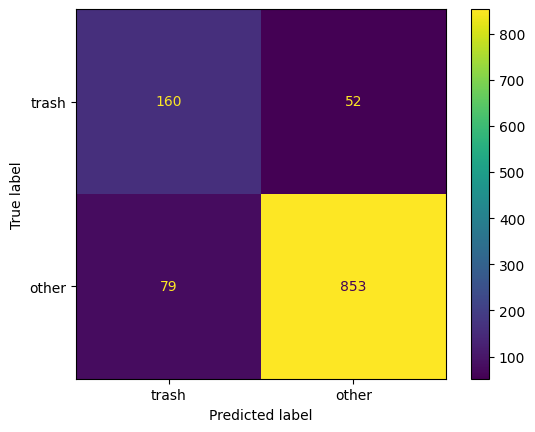

In [112]:
show_confusion_matrix(learn, dls)

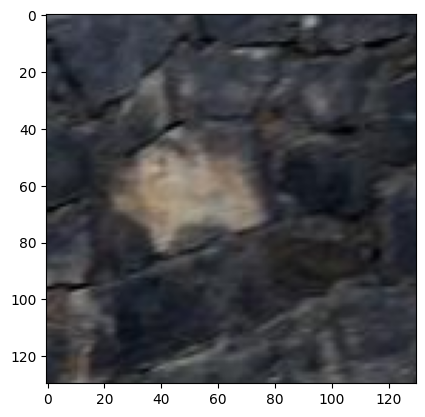

In [133]:
plt.imshow(get_image_from_input_tensor(valid_ds[23][0]))

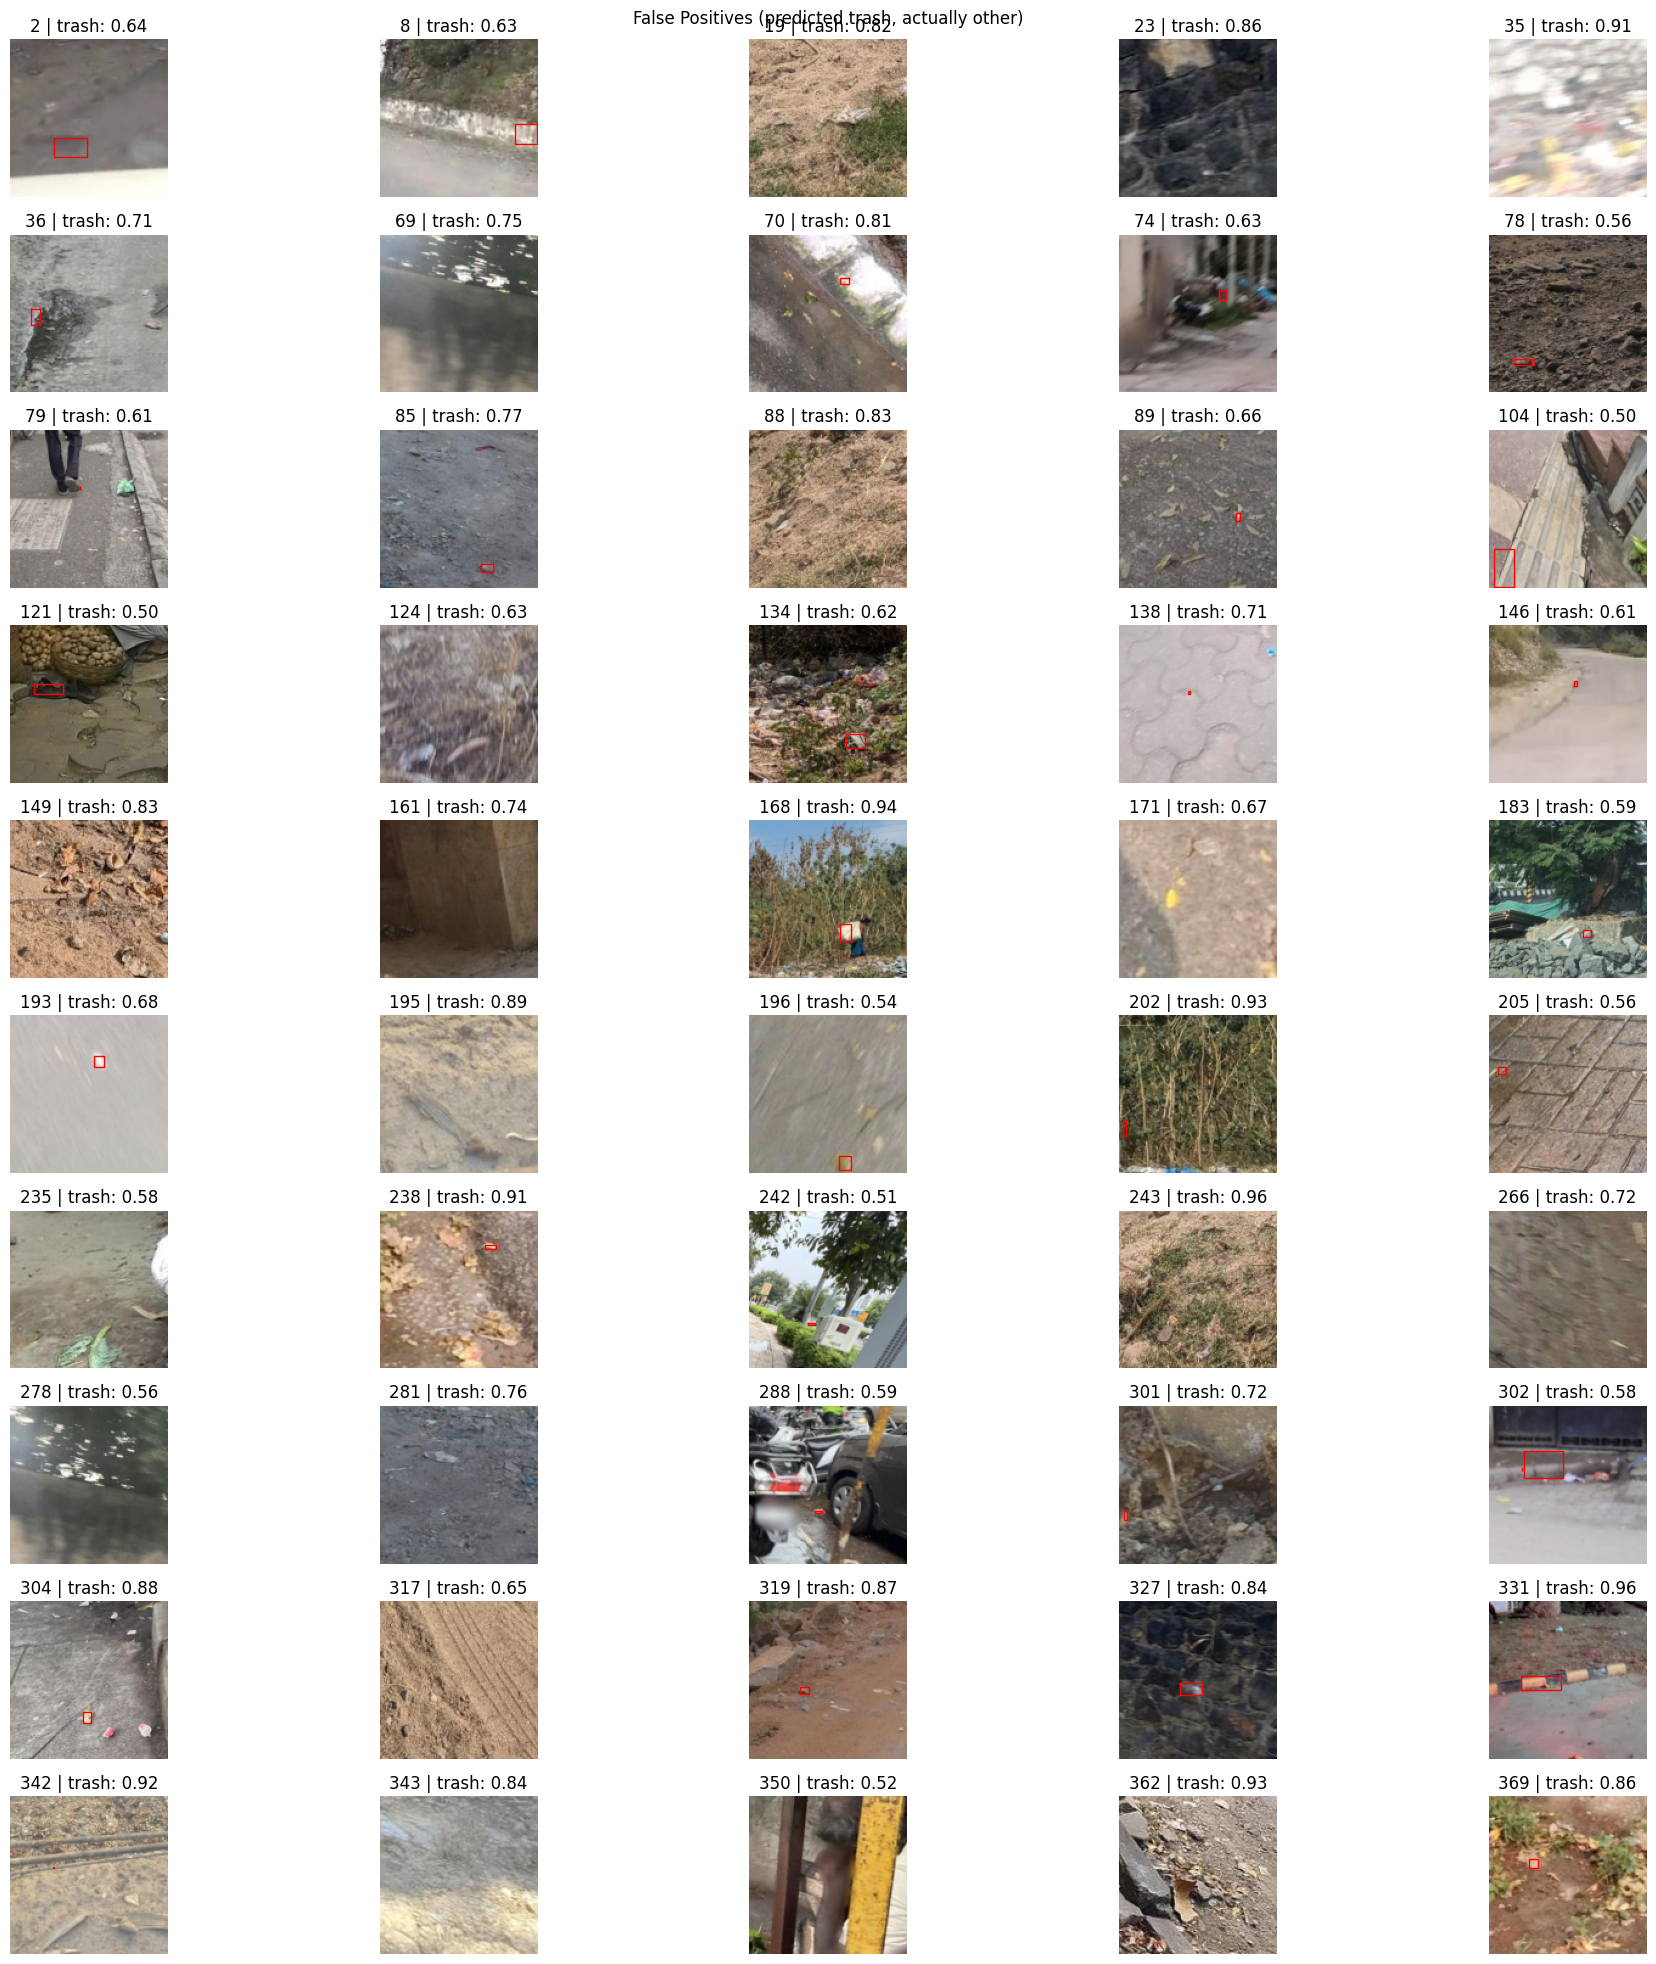

In [116]:
show_images(valid_ds, fp_idxs, all_preds, "False Positives (predicted trash, actually other)", 10)

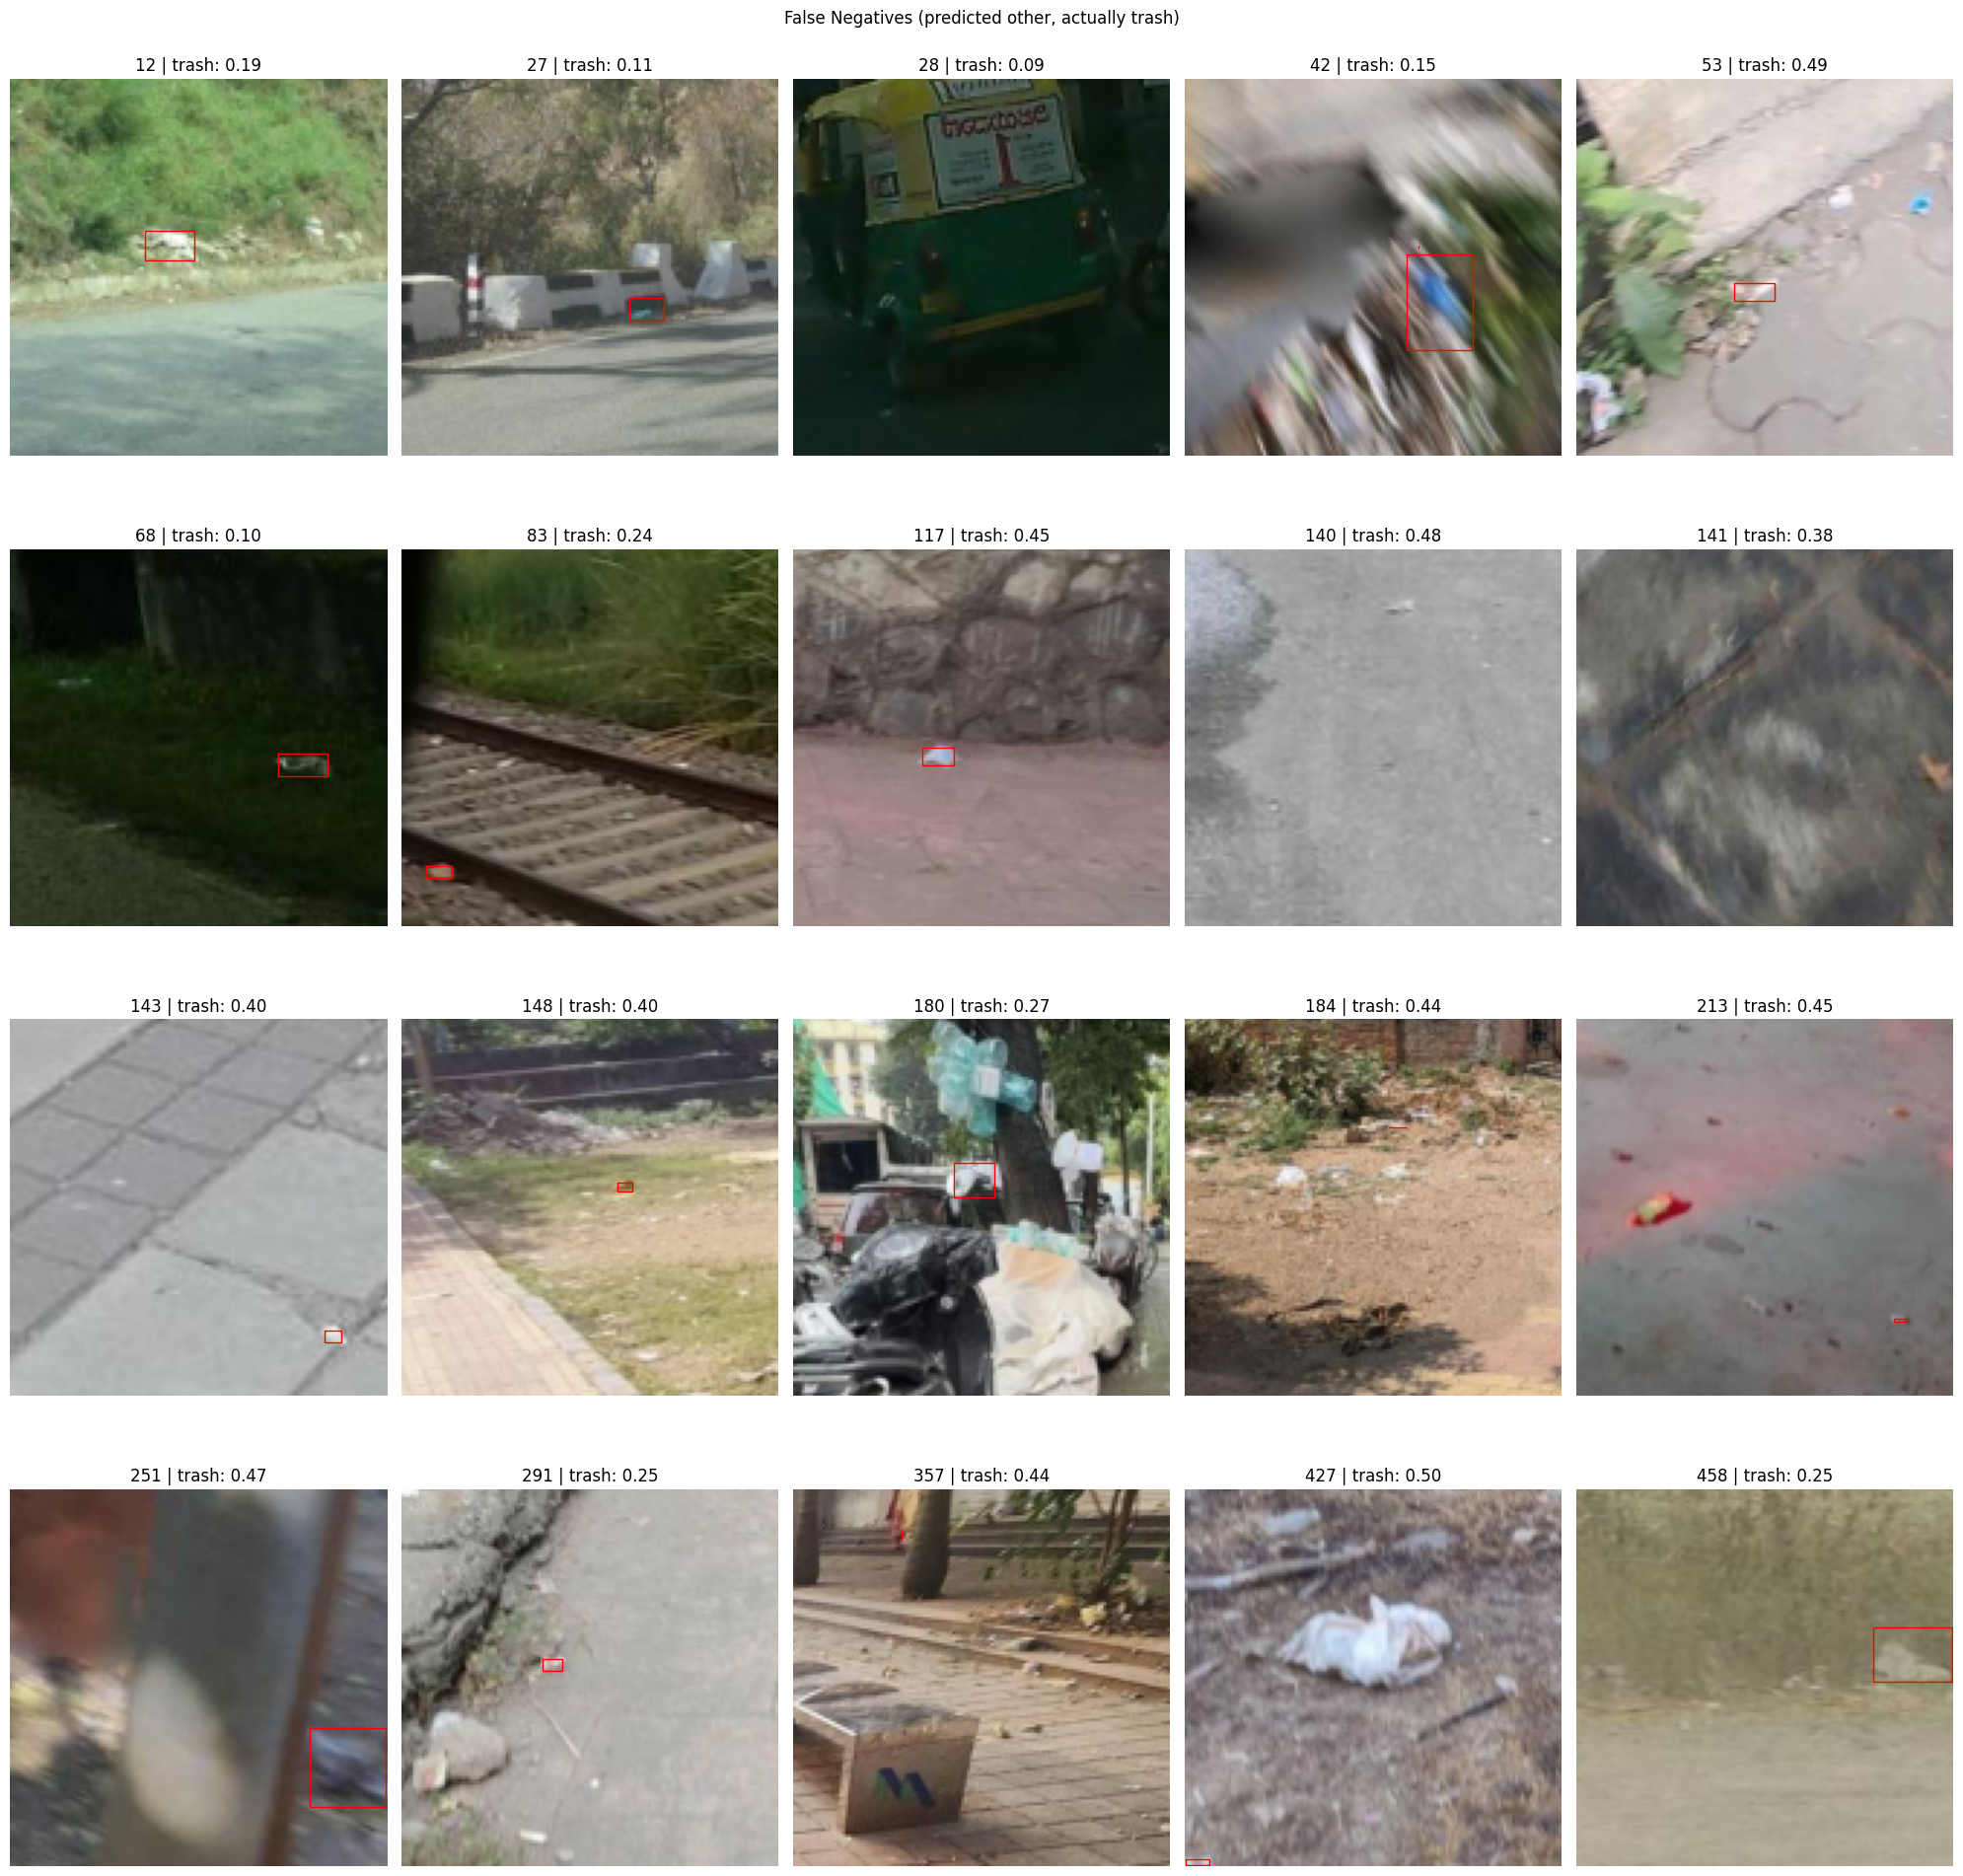

In [117]:
show_images(valid_ds, fn_idxs, all_preds, "False Negatives (predicted other, actually trash)")